# Observation Bias Campaign: First Run Review

This notebook reviews the first full-Zernike observation-bias campaign:

`Results/observation_bias_campaign/full_zernike_prior_draw_5cases_5x20_shotnoise`

The review has two evidence layers:

- actual 5-summary image-backed updates for each prior-draw case,
- forecast/extrapolation diagnostics to the 1800-subblock single-observation target.

The 1800-subblock forecast is not the same as running 1800 real image-backed subblock solves. It is a score/information extrapolation built from the completed summaries, and should be interpreted as a forecast layer rather than as completed 30-minute image-backed inference.


In [1]:
from pathlib import Path

RUN_ROOT = Path(
    "Results/observation_bias_campaign/"
    "full_zernike_prior_draw_5cases_5x20_shotnoise"
)

SINGLE_OBSERVATION_N_SUBBLOCKS = 1800
SEPARATION_LABEL = "source.separation_as"
TOP_N_WEAK_MODES = 8
TOP_N_EIGEN_CONTRIBUTORS = 8
SAVE_FIGURES = False


## 1. Load Artifacts

This section loads only existing campaign artifacts. Major root-level files are required and intentionally fail loudly if absent; weaker optional diagnostics can be empty or absent without stopping the review.


In [2]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from pandas.errors import EmptyDataError

plt.rcParams.update({
    "figure.figsize": (9, 4.8),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

if not RUN_ROOT.exists():
    configured_run_root = RUN_ROOT
    for base in [Path.cwd(), *Path.cwd().parents]:
        candidate = base / configured_run_root
        if candidate.exists():
            RUN_ROOT = candidate
            break

REQUIRED_FILES = [
    "campaign_summary.json",
    "forecast_summary.json",
    "science_summary.csv",
    "posterior_by_label.csv",
    "forecast_results.csv",
    "forecast_trial_results.csv",
    "forecast_information_diagnostics.csv",
    "eigenvalues_accumulated_information.csv",
    "eigenvalues_posterior_precision.csv",
    "eigenmode_contributors_accumulated_information.csv",
    "eigenmode_projection_accumulated_information.csv",
]
OPTIONAL_FILES = [
    "weak_mode_summary_accumulated_information.csv",
    "weak_mode_summary_posterior_precision.csv",
]


def load_json(path: Path) -> dict:
    with path.open("r") as f:
        return json.load(f)


def load_csv(path: Path, required: bool = True) -> pd.DataFrame:
    try:
        return pd.read_csv(path)
    except EmptyDataError:
        if required:
            raise
        return pd.DataFrame()
    except FileNotFoundError:
        if required:
            raise
        return pd.DataFrame()


def label_group(label: str) -> str:
    if label.startswith("source."):
        return "source"
    if label.startswith("optics.plate_scale"):
        return "optics.plate_scale"
    if label.startswith("optics.primary.zernike"):
        return "optics.primary_zernikes"
    if label.startswith("optics.secondary.zernike"):
        return "optics.secondary_zernikes"
    return label.split(".", 1)[0]


def savefig(name: str) -> None:
    if SAVE_FIGURES:
        out = RUN_ROOT / "notebook_review_figures"
        out.mkdir(parents=True, exist_ok=True)
        plt.savefig(out / name, dpi=160, bbox_inches="tight")


def short_mode(mode: str) -> str:
    return str(mode).replace("fixed_information_score_noise", "fixed score-noise")

missing = [name for name in REQUIRED_FILES if not (RUN_ROOT / name).exists()]
if missing:
    raise FileNotFoundError(f"Missing required campaign artifacts under {RUN_ROOT}: {missing}")

campaign_summary = load_json(RUN_ROOT / "campaign_summary.json")
forecast_summary = load_json(RUN_ROOT / "forecast_summary.json")
science = load_csv(RUN_ROOT / "science_summary.csv")
posterior = load_csv(RUN_ROOT / "posterior_by_label.csv")
forecast = load_csv(RUN_ROOT / "forecast_results.csv")
forecast_trials = load_csv(RUN_ROOT / "forecast_trial_results.csv")
forecast_info = load_csv(RUN_ROOT / "forecast_information_diagnostics.csv")
eig_accum = load_csv(RUN_ROOT / "eigenvalues_accumulated_information.csv")
eig_post = load_csv(RUN_ROOT / "eigenvalues_posterior_precision.csv")
contributors = load_csv(RUN_ROOT / "eigenmode_contributors_accumulated_information.csv")
projection = load_csv(RUN_ROOT / "eigenmode_projection_accumulated_information.csv")
weak_accum = load_csv(RUN_ROOT / "weak_mode_summary_accumulated_information.csv", required=False)
weak_post = load_csv(RUN_ROOT / "weak_mode_summary_posterior_precision.csv", required=False)

audit_paths = sorted(RUN_ROOT.glob("subblock_runs/*/subblock_*/study/schur_summary/schur_summary_audit.json"))

availability = []
for name in REQUIRED_FILES + OPTIONAL_FILES:
    p = RUN_ROOT / name
    availability.append({
        "artifact": name,
        "exists": p.exists(),
        "bytes": p.stat().st_size if p.exists() else np.nan,
        "required": name in REQUIRED_FILES,
    })
availability.append({
    "artifact": "subblock audit JSON files",
    "exists": bool(audit_paths),
    "bytes": np.nan,
    "required": False,
    "count": len(audit_paths),
})
display(pd.DataFrame(availability))


,artifact,exists,bytes,required,count
0,campaign_summary.json,True,9668.0,True,NaN
1,forecast_summary.json,True,4371.0,True,NaN
2,science_summary.csv,True,1381.0,True,NaN
3,posterior_by_label.csv,True,26811.0,True,NaN
4,forecast_results.csv,True,35032.0,True,NaN
5,forecast_trial_results.csv,True,1334006.0,True,NaN
6,forecast_information_diagnostics.csv,True,12027.0,True,NaN
7,eigenvalues_accumulated_information.csv,True,8890.0,True,NaN
8,eigenvalues_posterior_precision.csv,True,8662.0,True,NaN
9,eigenmode_contributors_accumulated_information...,True,99745.0,True,NaN


## 2. Campaign Overview

This run used 5 prior draws and 5 actual summaries per draw. The campaign used a 20-parameter full-Zernike observation state. The forecast layer extrapolated to 1800 subblocks, equivalent to 30 minutes at 1 second per subblock.


In [3]:
actual_summary_count = int(science.shape[0] and forecast.loc[forecast["is_actual_summary_count"].astype(bool), "n_subblocks"].mode().iloc[0])
forecast_modes = ", ".join(sorted(map(str, forecast["forecast_mode"].dropna().unique())))
target_rows = forecast[forecast["n_subblocks"].eq(SINGLE_OBSERVATION_N_SUBBLOCKS)]

overview = pd.DataFrame([
    ("run root", str(RUN_ROOT)),
    ("number of cases", campaign_summary.get("n_cases", science["case_name"].nunique())),
    ("n_theta", campaign_summary.get("n_theta", posterior["theta_label"].nunique())),
    ("eigen sources", ", ".join(campaign_summary.get("eigen_sources", []))),
    ("actual summaries per case", actual_summary_count),
    ("forecast enabled", forecast_summary.get("enabled", campaign_summary.get("forecast", {}).get("enabled"))),
    ("forecast modes", forecast_modes),
    ("single-observation target subblocks", SINGLE_OBSERVATION_N_SUBBLOCKS),
    ("equivalent duration at 1800 subblocks", f"{target_rows['equivalent_duration_min'].median():.1f} min"),
    ("number of forecast rows", len(forecast)),
    ("number of stochastic trial rows", len(forecast_trials)),
], columns=["item", "value"])
display(overview)


,item,value
0,run root,/Users/dmckeith/Documents/GitHub/dluxshera-san...
1,number of cases,5
2,n_theta,20
3,eigen sources,"accumulated_information, posterior_precision"
4,actual summaries per case,5
5,forecast enabled,True
6,forecast modes,"fixed_information_score_noise, replicate"
7,single-observation target subblocks,1800
8,equivalent duration at 1800 subblocks,30.0 min
9,number of forecast rows,90


## 3. Actual 5-Summary Science Result

These rows are the real image-backed Schur summaries, not forecast rows. The actual 5-summary updates are still mostly prior-dominated: posterior separation sigma remains close to 10 microarcseconds. Most cases move toward truth, but this is not yet a strong actual-data correction demonstration.


In [4]:
science = science.copy()
science["reference_separation_error_microas"] = 1e6 * (
    science["reference_separation_as"] - science["truth_separation_as"]
)
science["posterior_abs_error_microas"] = science["posterior_separation_error_microas"].abs()

science_table_cols = [
    "case_name",
    "reference_separation_error_microas",
    "posterior_separation_error_microas",
    "posterior_separation_sigma_microas",
    "posterior_separation_error_over_sigma",
    "separation_correction_fraction",
    "moves_separation_toward_truth",
]
display(science[science_table_cols].round(4))


,case_name,reference_separation_error_microas,posterior_separation_error_microas,posterior_separation_sigma_microas,posterior_separation_error_over_sigma,separation_correction_fraction,moves_separation_toward_truth
0,prior_draw_000,-14.2383,-13.5311,9.9619,-1.3583,0.0497,True
1,prior_draw_001,13.2230,12.9629,9.9619,1.3013,0.0197,True
2,prior_draw_002,3.1290,3.6575,9.9619,0.3672,-0.1689,False
3,prior_draw_003,-0.7127,-0.0374,9.9619,-0.0038,0.9476,True
4,prior_draw_004,-2.2364,-0.9728,9.9619,-0.0976,0.5650,True


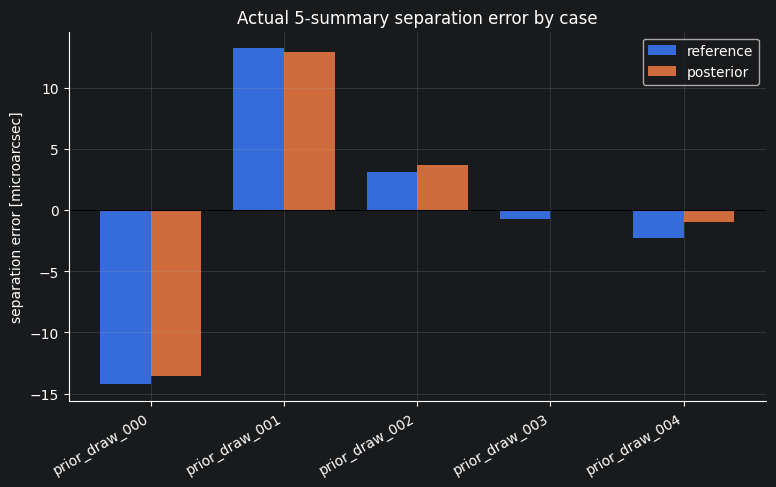

In [5]:
x = np.arange(len(science))
width = 0.38
fig, ax = plt.subplots()
ax.bar(x - width/2, science["reference_separation_error_microas"], width, label="reference")
ax.bar(x + width/2, science["posterior_separation_error_microas"], width, label="posterior")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x, science["case_name"], rotation=30, ha="right")
ax.set_ylabel("separation error [microarcsec]")
ax.set_title("Actual 5-summary separation error by case")
ax.legend()
savefig("actual_separation_error_by_case.png")
plt.show()


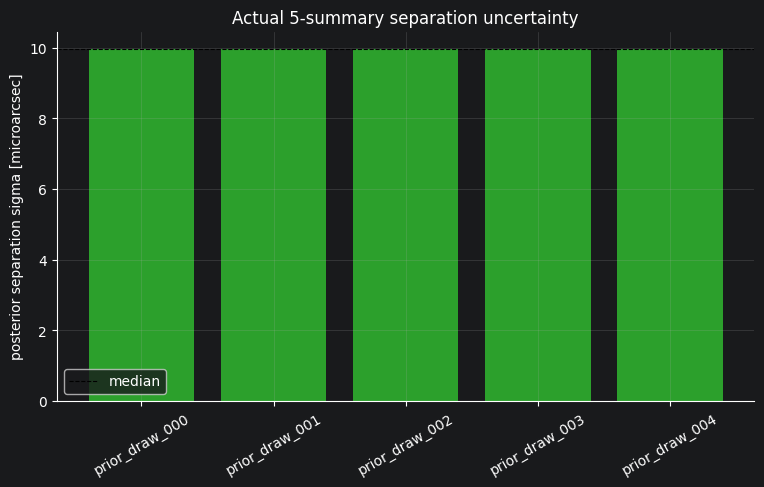

In [6]:
fig, ax = plt.subplots()
ax.bar(science["case_name"], science["posterior_separation_sigma_microas"], color="tab:green")
ax.axhline(science["posterior_separation_sigma_microas"].median(), color="black", linewidth=0.8, linestyle="--", label="median")
ax.set_ylabel("posterior separation sigma [microarcsec]")
ax.set_title("Actual 5-summary separation uncertainty")
ax.tick_params(axis="x", rotation=30)
ax.legend()
savefig("actual_separation_sigma_by_case.png")
plt.show()


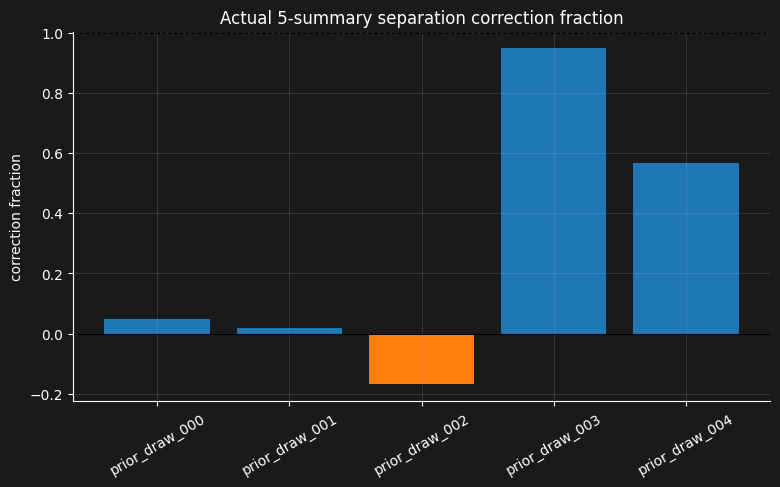

In [7]:
fig, ax = plt.subplots()
colors = np.where(science["moves_separation_toward_truth"], "tab:blue", "tab:orange")
ax.bar(science["case_name"], science["separation_correction_fraction"], color=colors)
ax.axhline(0, color="black", linewidth=0.8)
ax.axhline(1, color="black", linewidth=0.8, linestyle="--")
ax.set_ylabel("correction fraction")
ax.set_title("Actual 5-summary separation correction fraction")
ax.tick_params(axis="x", rotation=30)
savefig("actual_separation_correction_fraction_by_case.png")
plt.show()


## 4. Posterior Corrections By Parameter Group

Primary Zernikes appear more strongly constrained than secondary Zernikes, while secondary Zernikes remain more prior-dominated. This is useful evidence that the full-Zernike campaign is exposing optical degeneracy structure rather than merely returning a scalar separation result.


In [8]:
posterior = posterior.copy()
posterior["label_group"] = posterior["theta_label"].map(label_group)
posterior["abs_posterior_error_over_sigma"] = posterior["posterior_error_over_sigma"].abs()

group_summary = (
    posterior.groupby("label_group", as_index=False)
    .agg(
        rows=("theta_label", "count"),
        median_correction_fraction=("correction_fraction", "median"),
        median_residual_fraction=("residual_fraction", "median"),
        median_abs_posterior_error_over_sigma=("abs_posterior_error_over_sigma", "median"),
        mean_posterior_sigma=("posterior_sigma", "mean"),
        max_abs_posterior_error_over_sigma=("abs_posterior_error_over_sigma", "max"),
    )
    .sort_values("label_group")
)
display(group_summary.round(4))


,label_group,rows,median_correction_fraction,median_residual_fraction,median_abs_posterior_error_over_sigma,mean_posterior_sigma,max_abs_posterior_error_over_sigma
0,optics.plate_scale,5,1.1226,-0.1226,1.4564,0.0000,1.7093
1,optics.primary_zernikes,40,0.8685,0.1315,0.6604,0.0432,1.7543
2,optics.secondary_zernikes,40,0.3221,0.6779,0.7028,0.0896,1.7096
3,source,15,0.0497,0.9503,1.3583,0.0000,9.5084


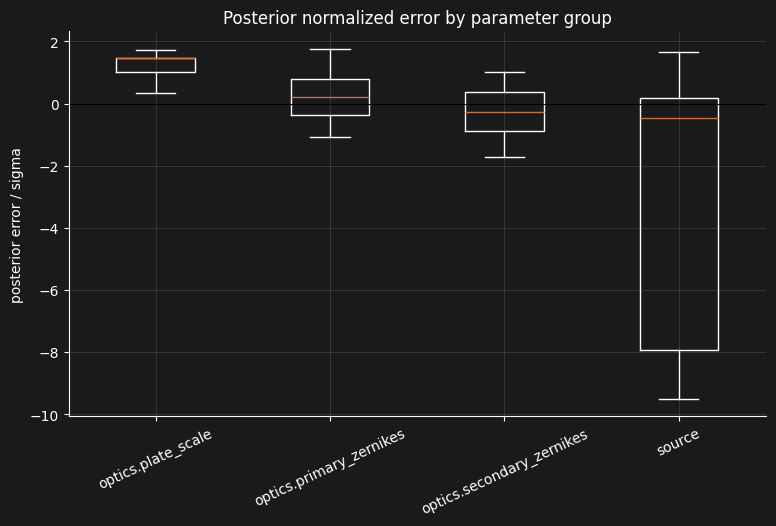

In [9]:
groups = list(group_summary["label_group"])
data = [posterior.loc[posterior["label_group"].eq(g), "posterior_error_over_sigma"].dropna() for g in groups]
fig, ax = plt.subplots(figsize=(9, 5))
ax.boxplot(data, tick_labels=groups, showfliers=True)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("posterior error / sigma")
ax.set_title("Posterior normalized error by parameter group")
ax.tick_params(axis="x", rotation=25)
savefig("posterior_error_over_sigma_by_group.png")
plt.show()


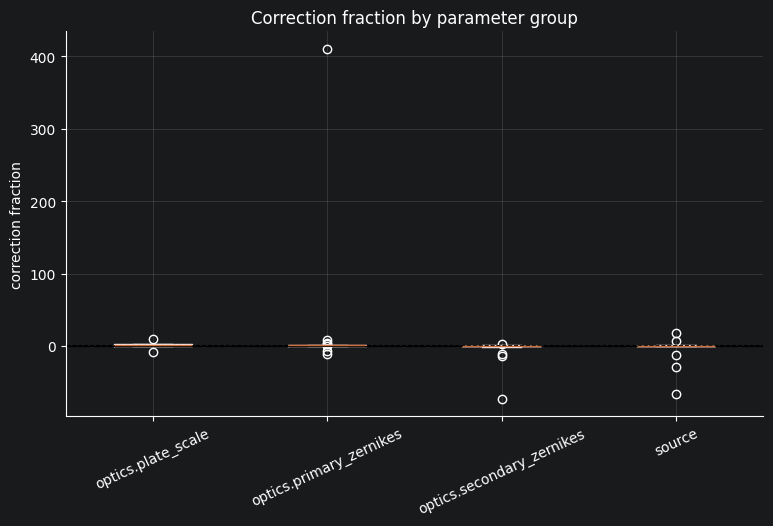

In [10]:
data = [posterior.loc[posterior["label_group"].eq(g), "correction_fraction"].dropna() for g in groups]
fig, ax = plt.subplots(figsize=(9, 5))
ax.boxplot(data, tick_labels=groups, showfliers=True)
ax.axhline(0, color="black", linewidth=0.8)
ax.axhline(1, color="black", linewidth=0.8, linestyle="--")
ax.set_ylabel("correction fraction")
ax.set_title("Correction fraction by parameter group")
ax.tick_params(axis="x", rotation=25)
savefig("correction_fraction_by_group.png")
plt.show()


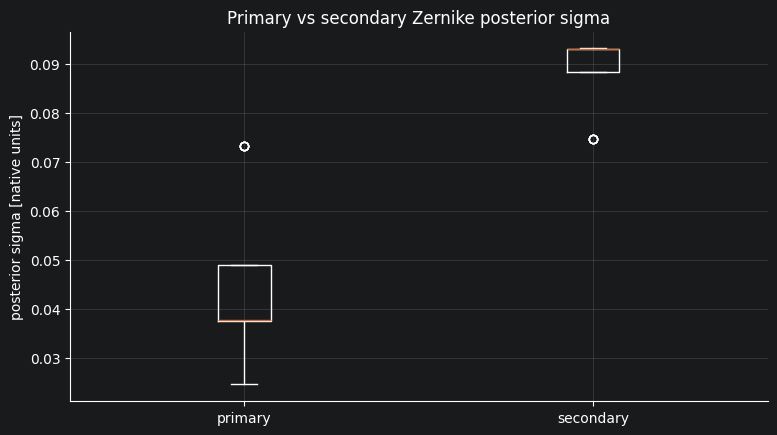

In [11]:
z_groups = ["optics.primary_zernikes", "optics.secondary_zernikes"]
data = [posterior.loc[posterior["label_group"].eq(g), "posterior_sigma"].dropna() for g in z_groups]
fig, ax = plt.subplots()
ax.boxplot(data, tick_labels=["primary", "secondary"], showfliers=True)
ax.set_ylabel("posterior sigma [native units]")
ax.set_title("Primary vs secondary Zernike posterior sigma")
savefig("zernike_posterior_sigma_primary_vs_secondary.png")
plt.show()


## 5. Log-Flux Red Flag

The first overnight review found a coherent downward log-flux shift. This may indicate reduced-score bias, variance-model mismatch, exposure/log-flux normalization mismatch, residual registration absorption, or Schur linearization issues. This should be investigated before interpreting photometric correction as reliable.


In [12]:
log_flux = posterior[posterior["theta_label"].eq("source.log_flux_total")].copy()
log_cols = [
    "case_name",
    "reference_value",
    "posterior_mean",
    "posterior_shift",
    "posterior_error",
    "posterior_sigma",
    "posterior_error_over_sigma",
    "correction_fraction",
]
display(log_flux[log_cols].round(6))


,case_name,reference_value,posterior_mean,posterior_shift,posterior_error,posterior_sigma,posterior_error_over_sigma,correction_fraction
1,prior_draw_000,7.015664,7.015577,-0.000087,-0.000075,0.00001,-7.569822,6.916041
21,prior_draw_001,7.015649,7.015563,-0.000086,-0.000089,0.00001,-9.014680,-28.707533
41,prior_draw_002,7.015650,7.015563,-0.000087,-0.000089,0.00001,-8.979069,-66.792912
61,prior_draw_003,7.015657,7.015570,-0.000087,-0.000082,0.00001,-8.309393,18.311927
81,prior_draw_004,7.015645,7.015558,-0.000087,-0.000094,0.00001,-9.508376,-12.383220


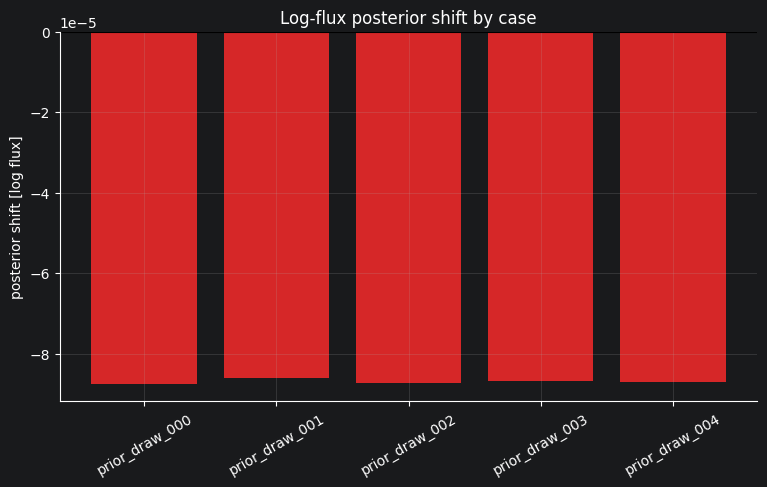

In [13]:
fig, ax = plt.subplots()
ax.bar(log_flux["case_name"], log_flux["posterior_shift"], color="tab:red")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("posterior shift [log flux]")
ax.set_title("Log-flux posterior shift by case")
ax.tick_params(axis="x", rotation=30)
savefig("log_flux_shift_by_case.png")
plt.show()


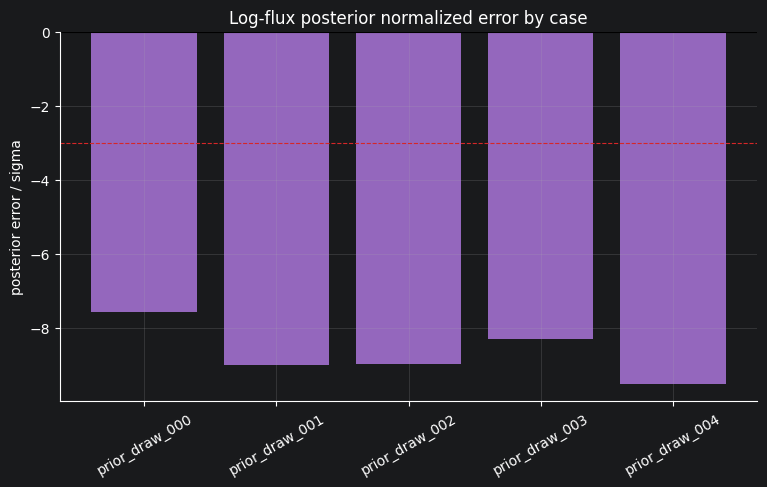

In [14]:
fig, ax = plt.subplots()
ax.bar(log_flux["case_name"], log_flux["posterior_error_over_sigma"], color="tab:purple")
ax.axhline(0, color="black", linewidth=0.8)
ax.axhline(-3, color="tab:red", linewidth=0.8, linestyle="--")
ax.set_ylabel("posterior error / sigma")
ax.set_title("Log-flux posterior normalized error by case")
ax.tick_params(axis="x", rotation=30)
savefig("log_flux_error_over_sigma_by_case.png")
plt.show()


## 6. Forecast To 1800 Subblocks

Fixed-information score-noise is the more relevant forecast for independent 30-minute accumulation. Replicate mode is a diagnostic that repeats reduced scores coherently. The stochastic forecast is encouraging: roughly 6.4 microarcsecond separation sigma at the 1800-subblock target. The replicate forecast produces large coherent errors and should be treated as a warning about score structure, not as an independent-noise forecast.


In [15]:
target = forecast[forecast["n_subblocks"].eq(SINGLE_OBSERVATION_N_SUBBLOCKS)].copy()
target_cols = [
    "case_name",
    "forecast_mode",
    "n_actual_summaries",
    "equivalent_duration_min",
    "separation_posterior_sigma_microas",
    "separation_posterior_error_microas",
    "separation_error_rms_microas",
    "prior_sigma_source",
]
display(target[target_cols].sort_values(["case_name", "forecast_mode"]).round(4))


,case_name,forecast_mode,n_actual_summaries,equivalent_duration_min,separation_posterior_sigma_microas,separation_posterior_error_microas,separation_error_rms_microas,prior_sigma_source
17,prior_draw_000,fixed_information_score_noise,5,30.0,6.3783,-10.9742,7.9423,prior_draw_config
8,prior_draw_000,replicate,5,30.0,6.3783,206.4882,NaN,prior_draw_config
35,prior_draw_001,fixed_information_score_noise,5,30.0,6.3777,5.8740,7.4590,prior_draw_config
26,prior_draw_001,replicate,5,30.0,6.3777,197.0510,NaN,prior_draw_config
53,prior_draw_002,fixed_information_score_noise,5,30.0,6.3782,3.8332,5.7590,prior_draw_config
44,prior_draw_002,replicate,5,30.0,6.3782,213.8826,NaN,prior_draw_config
71,prior_draw_003,fixed_information_score_noise,5,30.0,6.3772,-0.4732,4.8046,prior_draw_config
62,prior_draw_003,replicate,5,30.0,6.3772,212.9155,NaN,prior_draw_config
89,prior_draw_004,fixed_information_score_noise,5,30.0,6.3771,-10.1580,4.9021,prior_draw_config
80,prior_draw_004,replicate,5,30.0,6.3771,230.3057,NaN,prior_draw_config


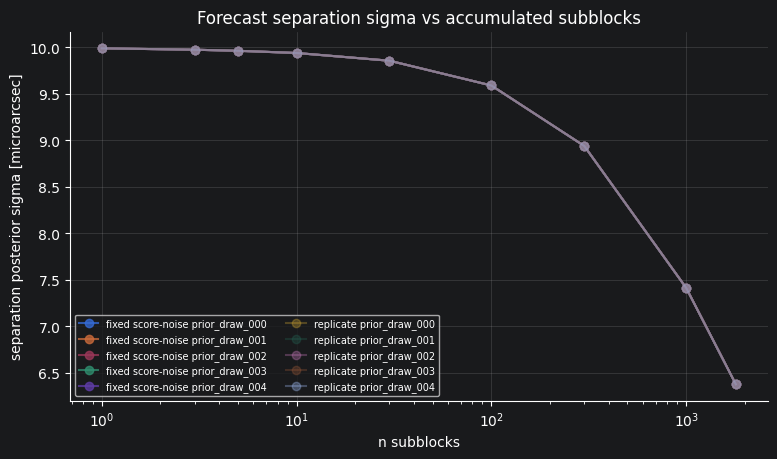

In [16]:
fig, ax = plt.subplots()
for (mode, case), df in forecast.groupby(["forecast_mode", "case_name"]):
    alpha = 0.35 if mode == "replicate" else 0.75
    ax.plot(df["n_subblocks"], df["separation_posterior_sigma_microas"], marker="o", alpha=alpha, label=f"{short_mode(mode)} {case}")
ax.set_xscale("log")
ax.set_xlabel("n subblocks")
ax.set_ylabel("separation posterior sigma [microarcsec]")
ax.set_title("Forecast separation sigma vs accumulated subblocks")
ax.legend(fontsize=7, ncols=2)
savefig("forecast_sigma_vs_n_subblocks.png")
plt.show()


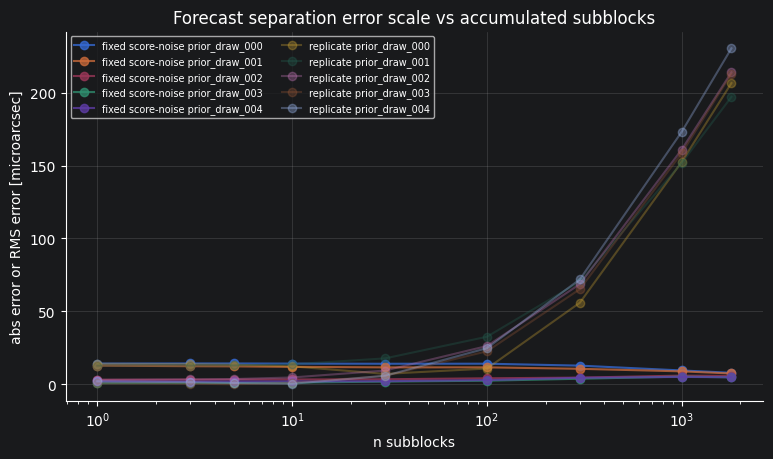

In [17]:
fig, ax = plt.subplots()
for (mode, case), df in forecast.groupby(["forecast_mode", "case_name"]):
    y = df["separation_error_rms_microas"].where(df["separation_error_rms_microas"].notna(), df["separation_posterior_error_microas"].abs())
    alpha = 0.35 if mode == "replicate" else 0.75
    ax.plot(df["n_subblocks"], y, marker="o", alpha=alpha, label=f"{short_mode(mode)} {case}")
ax.set_xscale("log")
ax.set_xlabel("n subblocks")
ax.set_ylabel("abs error or RMS error [microarcsec]")
ax.set_title("Forecast separation error scale vs accumulated subblocks")
ax.legend(fontsize=7, ncols=2)
savefig("forecast_error_vs_n_subblocks.png")
plt.show()


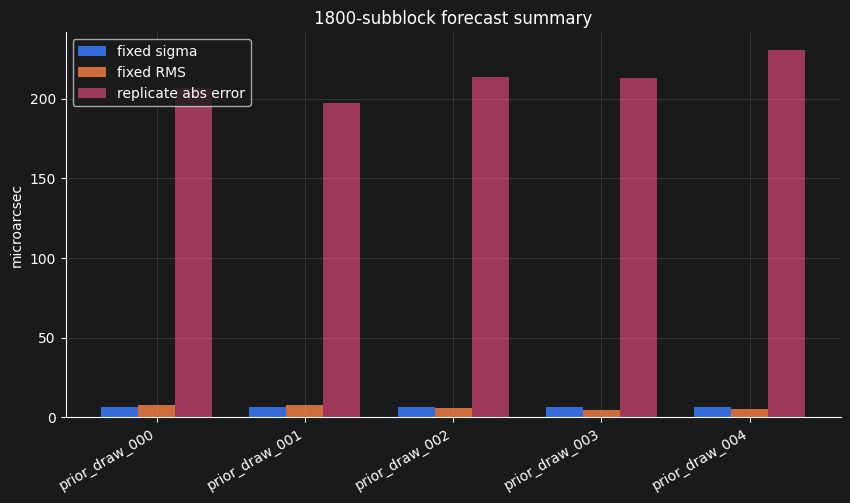

In [18]:
bar_rows = []
for case, df in target.groupby("case_name"):
    fixed = df[df["forecast_mode"].eq("fixed_information_score_noise")]
    repl = df[df["forecast_mode"].eq("replicate")]
    if not fixed.empty:
        bar_rows.append((case, "fixed sigma", fixed["separation_posterior_sigma_microas"].iloc[0]))
        bar_rows.append((case, "fixed RMS", fixed["separation_error_rms_microas"].iloc[0]))
    if not repl.empty:
        bar_rows.append((case, "replicate abs error", abs(repl["separation_posterior_error_microas"].iloc[0])))
bar_df = pd.DataFrame(bar_rows, columns=["case_name", "metric", "microas"])

fig, ax = plt.subplots(figsize=(10, 5))
metrics = ["fixed sigma", "fixed RMS", "replicate abs error"]
x = np.arange(bar_df["case_name"].nunique())
width = 0.25
for i, metric in enumerate(metrics):
    vals = bar_df[bar_df["metric"].eq(metric)].set_index("case_name").reindex(sorted(bar_df["case_name"].unique()))["microas"]
    ax.bar(x + (i - 1) * width, vals, width, label=metric)
ax.set_xticks(x, sorted(bar_df["case_name"].unique()), rotation=30, ha="right")
ax.set_ylabel("microarcsec")
ax.set_title("1800-subblock forecast summary")
ax.legend()
savefig("forecast_1800_summary_bar.png")
plt.show()


## 7. Stochastic Forecast Trial Distribution

This focuses on `fixed_information_score_noise` at 1800 subblocks. Compare the RMS errors to posterior sigma and check whether the trial distributions are centered near zero. The score-noise model is Fisher-consistent, but it is not yet calibrated by a larger real-summary Monte Carlo.


In [19]:
trial_1800 = forecast_trials[
    forecast_trials["forecast_mode"].eq("fixed_information_score_noise")
    & forecast_trials["n_subblocks"].eq(SINGLE_OBSERVATION_N_SUBBLOCKS)
].copy()

trial_summary = (
    trial_1800.groupby("case_name", as_index=False)
    .agg(
        mean_error_microas=("separation_posterior_error_microas", "mean"),
        std_error_microas=("separation_posterior_error_microas", "std"),
        rms_error_microas=("separation_posterior_error_microas", lambda s: float(np.sqrt(np.mean(np.square(s))))),
        p16_error_microas=("separation_posterior_error_microas", lambda s: s.quantile(0.16)),
        p50_error_microas=("separation_posterior_error_microas", "median"),
        p84_error_microas=("separation_posterior_error_microas", lambda s: s.quantile(0.84)),
        posterior_sigma_mean_microas=("separation_posterior_sigma_microas", "mean"),
        posterior_sigma_median_microas=("separation_posterior_sigma_microas", "median"),
    )
)
display(trial_summary.round(4))


,case_name,mean_error_microas,std_error_microas,rms_error_microas,p16_error_microas,p50_error_microas,p84_error_microas,posterior_sigma_mean_microas,posterior_sigma_median_microas
0,prior_draw_000,-6.4673,4.6335,7.9423,-10.7469,-6.1996,-1.9444,6.3783,6.3783
1,prior_draw_001,5.3799,5.1926,7.4590,-0.1642,5.3692,10.1797,6.3777,6.3777
2,prior_draw_002,1.4523,5.6009,5.7590,-3.7112,1.6368,6.6733,6.3782,6.3782
3,prior_draw_003,-1.0450,4.7132,4.8046,-5.1992,-0.7947,3.3568,6.3772,6.3772
4,prior_draw_004,-0.2730,4.9191,4.9021,-5.2994,-0.3120,4.7928,6.3771,6.3771


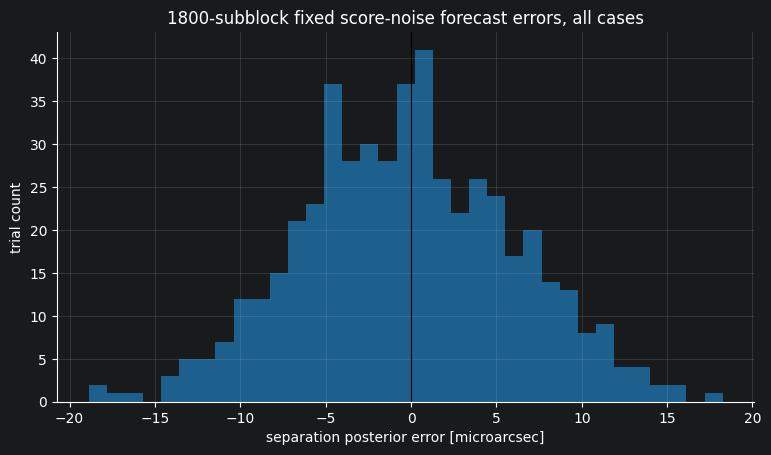

In [20]:
fig, ax = plt.subplots()
ax.hist(trial_1800["separation_posterior_error_microas"], bins=35, color="tab:blue", alpha=0.75)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("separation posterior error [microarcsec]")
ax.set_ylabel("trial count")
ax.set_title("1800-subblock fixed score-noise forecast errors, all cases")
savefig("forecast_1800_error_distribution.png")
plt.show()


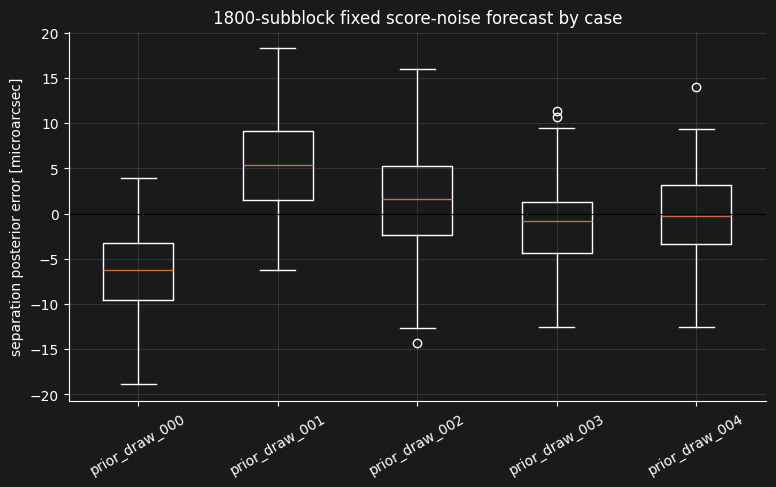

In [21]:
case_order = sorted(trial_1800["case_name"].unique())
data = [trial_1800.loc[trial_1800["case_name"].eq(case), "separation_posterior_error_microas"] for case in case_order]
fig, ax = plt.subplots()
ax.boxplot(data, tick_labels=case_order, showfliers=True)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("separation posterior error [microarcsec]")
ax.set_title("1800-subblock fixed score-noise forecast by case")
ax.tick_params(axis="x", rotation=30)
savefig("forecast_1800_error_boxplot_by_case.png")
plt.show()


## 8. Eigenvalue Spectra

Accumulated information answers “what do the image summaries measure?” Posterior precision answers “what do prior + data constrain?” Accumulated-information weak modes are the more direct degeneracy diagnostic.


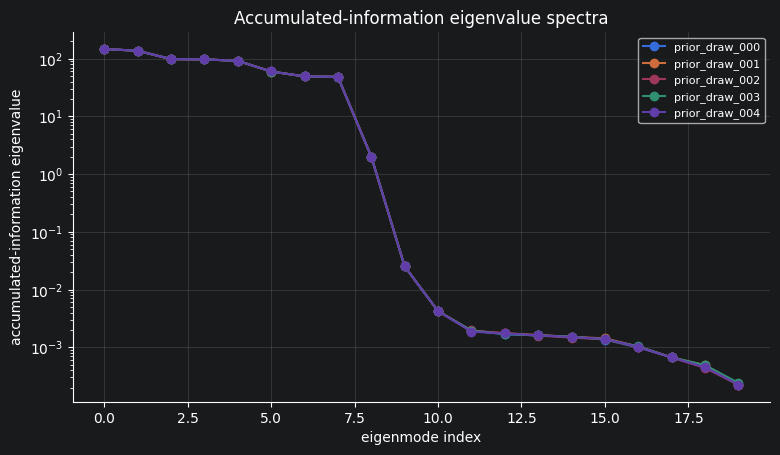

In [22]:
fig, ax = plt.subplots()
for case, df in eig_accum.groupby("case_name"):
    ax.semilogy(df["mode_index"], df["eigenvalue"], marker="o", label=case)
ax.set_xlabel("eigenmode index")
ax.set_ylabel("accumulated-information eigenvalue")
ax.set_title("Accumulated-information eigenvalue spectra")
ax.legend(fontsize=8)
savefig("accumulated_information_eigen_spectrum.png")
plt.show()


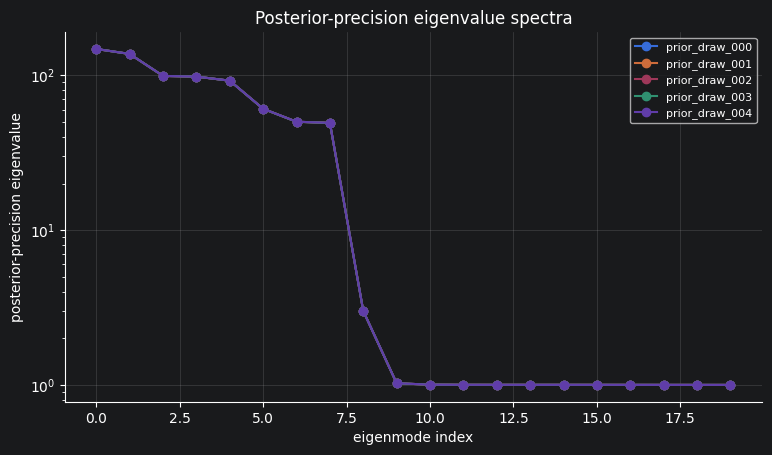

In [23]:
fig, ax = plt.subplots()
for case, df in eig_post.groupby("case_name"):
    ax.semilogy(df["mode_index"], df["eigenvalue"], marker="o", label=case)
ax.set_xlabel("eigenmode index")
ax.set_ylabel("posterior-precision eigenvalue")
ax.set_title("Posterior-precision eigenvalue spectra")
ax.legend(fontsize=8)
savefig("posterior_precision_eigen_spectrum.png")
plt.show()


## 9. Weak-Mode Contributor Review

Weak modes are expected to reveal M1/M2 Zernike degeneracy. Secondary-Zernike-heavy weak modes are a meaningful diagnostic result. Any weak mode with large separation weight should be flagged as relevant to science robustness.

The explicit weak-mode summary CSVs are empty in this first run, so this section derives the review from the weakest accumulated-information eigenmodes and their top contributors.


In [24]:
def contributor_group_weights(contrib_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for (case, mode), df in contrib_df.groupby(["case_name", "mode_index"]):
        denom = df["abs_coefficient"].sum()
        weights = df.groupby("label_group")["abs_coefficient"].sum() / denom if denom else pd.Series(dtype=float)
        top = "; ".join(
            f"{r.theta_label}:{r.coefficient:+.3f}"
            for r in df.sort_values("rank").head(3).itertuples()
        )
        rows.append({
            "case_name": case,
            "mode_index": mode,
            "source_scalar_weight": weights.get("source", 0.0),
            "separation_weight": df.loc[df["theta_label"].eq(SEPARATION_LABEL), "abs_coefficient"].sum() / denom if denom else 0.0,
            "plate_scale_weight": weights.get("optics.plate_scale", 0.0),
            "primary_zernike_weight": weights.get("optics.primary_zernikes", 0.0),
            "secondary_zernike_weight": weights.get("optics.secondary_zernikes", 0.0),
            "dominant_group": weights.idxmax() if len(weights) else None,
            "top_contributor_summary": top,
        })
    return pd.DataFrame(rows)

weak_modes = (
    eig_accum.sort_values(["case_name", "eigenvalue"], ascending=[True, True])
    .groupby("case_name", as_index=False)
    .head(TOP_N_WEAK_MODES)
    [["case_name", "mode_index", "eigenvalue", "sigma_equivalent"]]
)
weights = contributor_group_weights(contributors)
weak_review = weak_modes.merge(weights, on=["case_name", "mode_index"], how="left")
weak_cols = [
    "case_name",
    "mode_index",
    "eigenvalue",
    "dominant_group",
    "primary_zernike_weight",
    "secondary_zernike_weight",
    "separation_weight",
    "source_scalar_weight",
    "plate_scale_weight",
    "top_contributor_summary",
]
display(weak_review[weak_cols].round(4))


,case_name,mode_index,eigenvalue,dominant_group,primary_zernike_weight,secondary_zernike_weight,separation_weight,source_scalar_weight,plate_scale_weight,top_contributor_summary
0,prior_draw_000,19,0.0002,optics.secondary_zernikes,0.1756,0.8244,0.0000,0.0000,0.0,optics.secondary.zernike_coeffs_nm[0]:-0.779; ...
1,prior_draw_000,18,0.0004,optics.secondary_zernikes,0.2107,0.7893,0.0000,0.0000,0.0,optics.secondary.zernike_coeffs_nm[6]:-0.695; ...
2,prior_draw_000,17,0.0007,source,0.0549,0.1565,0.0000,0.7886,0.0,source.contrast:-0.993; optics.secondary.zerni...
3,prior_draw_000,16,0.0010,optics.secondary_zernikes,0.2704,0.6868,0.0428,0.0428,0.0,optics.secondary.zernike_coeffs_nm[1]:-0.636; ...
4,prior_draw_000,15,0.0014,optics.secondary_zernikes,0.1408,0.8592,0.0000,0.0000,0.0,optics.secondary.zernike_coeffs_nm[4]:-0.458; ...
5,prior_draw_000,14,0.0015,optics.secondary_zernikes,0.2453,0.7547,0.0000,0.0000,0.0,optics.secondary.zernike_coeffs_nm[5]:+0.671; ...
6,prior_draw_000,13,0.0016,optics.secondary_zernikes,0.2910,0.6550,0.0541,0.0541,0.0,optics.secondary.zernike_coeffs_nm[2]:-0.740; ...
7,prior_draw_000,12,0.0017,optics.secondary_zernikes,0.3071,0.6929,0.0000,0.0000,0.0,optics.secondary.zernike_coeffs_nm[3]:+0.628; ...
8,prior_draw_001,19,0.0002,optics.secondary_zernikes,0.1774,0.8226,0.0000,0.0000,0.0,optics.secondary.zernike_coeffs_nm[0]:+0.777; ...
9,prior_draw_001,18,0.0005,optics.secondary_zernikes,0.2108,0.7892,0.0000,0.0000,0.0,optics.secondary.zernike_coeffs_nm[6]:-0.702; ...


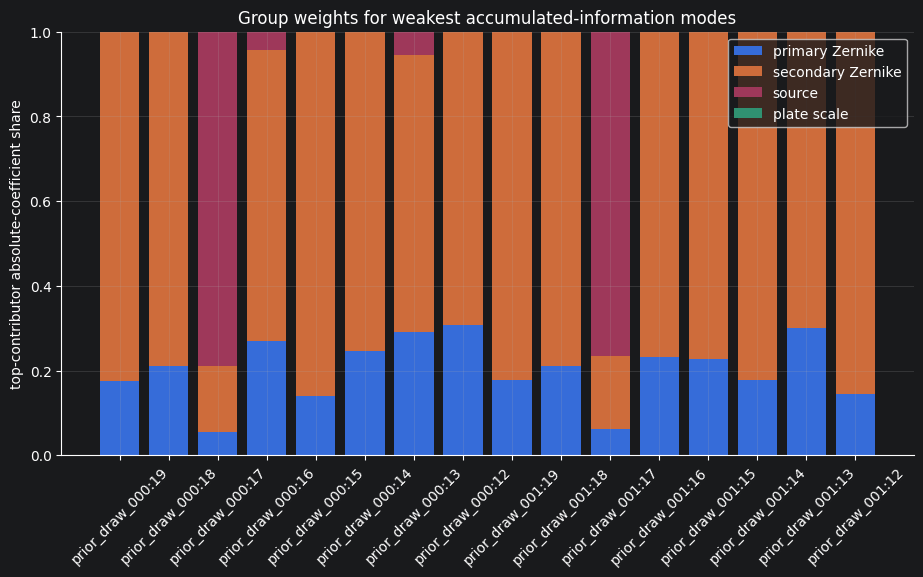

In [25]:
plot_weights = weak_review.copy()
plot_weights["case_mode"] = plot_weights["case_name"] + ":" + plot_weights["mode_index"].astype(str)
plot_weights = plot_weights.head(TOP_N_WEAK_MODES * 2)
fig, ax = plt.subplots(figsize=(11, 5.5))
bottom = np.zeros(len(plot_weights))
for col, label in [
    ("primary_zernike_weight", "primary Zernike"),
    ("secondary_zernike_weight", "secondary Zernike"),
    ("source_scalar_weight", "source"),
    ("plate_scale_weight", "plate scale"),
]:
    vals = plot_weights[col].fillna(0).to_numpy()
    ax.bar(plot_weights["case_mode"], vals, bottom=bottom, label=label)
    bottom += vals
ax.set_ylabel("top-contributor absolute-coefficient share")
ax.set_title("Group weights for weakest accumulated-information modes")
ax.tick_params(axis="x", rotation=45)
ax.legend()
savefig("weak_mode_group_weights.png")
plt.show()


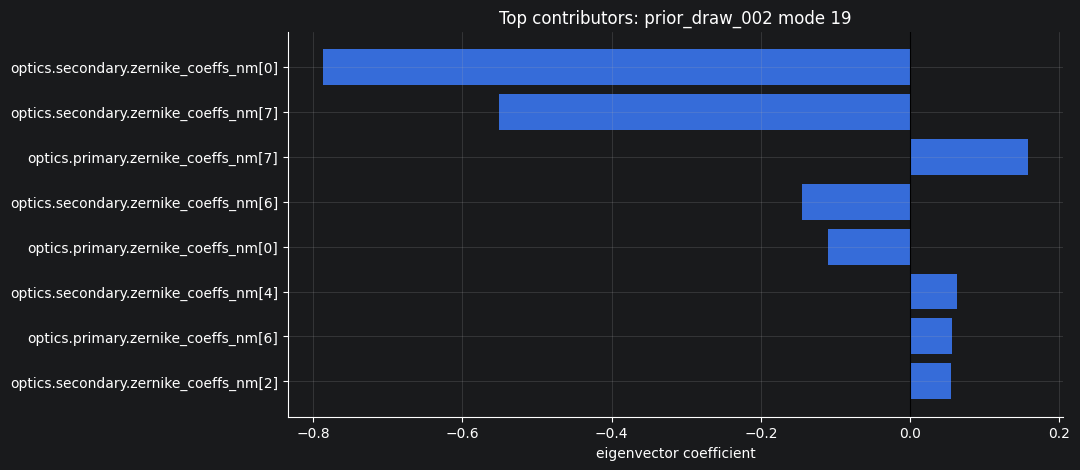

,case_name,mode_index,rank,theta_label,coefficient,abs_coefficient,label_group
472,prior_draw_002,19,1,optics.secondary.zernike_coeffs_nm[0],-0.7867,0.7867,optics.secondary_zernikes
473,prior_draw_002,19,2,optics.secondary.zernike_coeffs_nm[7],-0.5505,0.5505,optics.secondary_zernikes
474,prior_draw_002,19,3,optics.primary.zernike_coeffs_nm[7],0.1577,0.1577,optics.primary_zernikes
475,prior_draw_002,19,4,optics.secondary.zernike_coeffs_nm[6],-0.1452,0.1452,optics.secondary_zernikes
476,prior_draw_002,19,5,optics.primary.zernike_coeffs_nm[0],-0.1096,0.1096,optics.primary_zernikes
477,prior_draw_002,19,6,optics.secondary.zernike_coeffs_nm[4],0.0634,0.0634,optics.secondary_zernikes
478,prior_draw_002,19,7,optics.primary.zernike_coeffs_nm[6],0.0567,0.0567,optics.primary_zernikes
479,prior_draw_002,19,8,optics.secondary.zernike_coeffs_nm[2],0.0554,0.0554,optics.secondary_zernikes


In [26]:
representative = weak_review.sort_values("eigenvalue").iloc[0]
rep_contrib = contributors[
    contributors["case_name"].eq(representative["case_name"])
    & contributors["mode_index"].eq(representative["mode_index"])
].sort_values("rank").head(TOP_N_EIGEN_CONTRIBUTORS)
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(rep_contrib["theta_label"], rep_contrib["coefficient"])
ax.axvline(0, color="black", linewidth=0.8)
ax.invert_yaxis()
ax.set_xlabel("eigenvector coefficient")
ax.set_title(f"Top contributors: {representative['case_name']} mode {int(representative['mode_index'])}")
savefig("weak_mode_representative_contributors.png")
plt.show()

display(rep_contrib[["case_name", "mode_index", "rank", "theta_label", "coefficient", "abs_coefficient", "label_group"]].round(4))


## 10. Eigenmode Projection Review

This shows whether the prior-draw error is corrected in data-measured modes. Weak modes may remain prior-dominated. For the full-Zernike case, this is a better success criterion than recovering every physical Zernike coefficient independently.


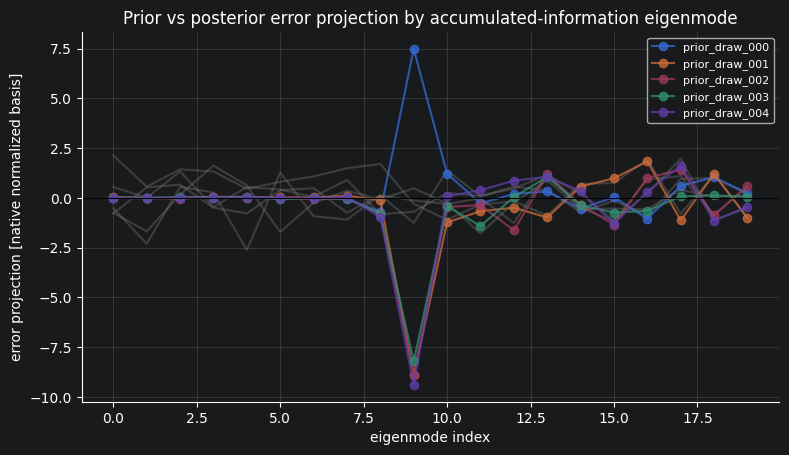

In [27]:
fig, ax = plt.subplots()
for case, df in projection.groupby("case_name"):
    df = df.sort_values("mode_index")
    ax.plot(df["mode_index"], df["prior_error_projection"], color="tab:gray", alpha=0.35)
    ax.plot(df["mode_index"], df["posterior_error_projection"], marker="o", alpha=0.75, label=case)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("eigenmode index")
ax.set_ylabel("error projection [native normalized basis]")
ax.set_title("Prior vs posterior error projection by accumulated-information eigenmode")
ax.legend(fontsize=8)
savefig("eigenmode_prior_vs_posterior_projection.png")
plt.show()


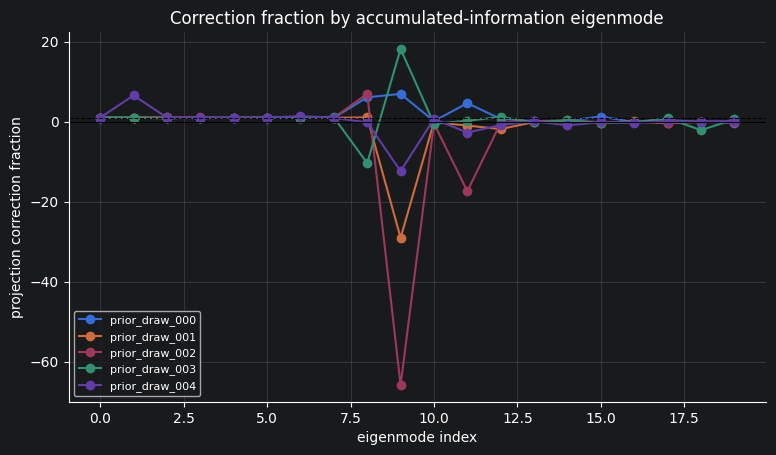

In [28]:
fig, ax = plt.subplots()
for case, df in projection.groupby("case_name"):
    ax.plot(df["mode_index"], df["correction_fraction_projection"], marker="o", label=case)
ax.axhline(0, color="black", linewidth=0.8)
ax.axhline(1, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("eigenmode index")
ax.set_ylabel("projection correction fraction")
ax.set_title("Correction fraction by accumulated-information eigenmode")
ax.legend(fontsize=8)
savefig("eigenmode_correction_fraction_projection.png")
plt.show()


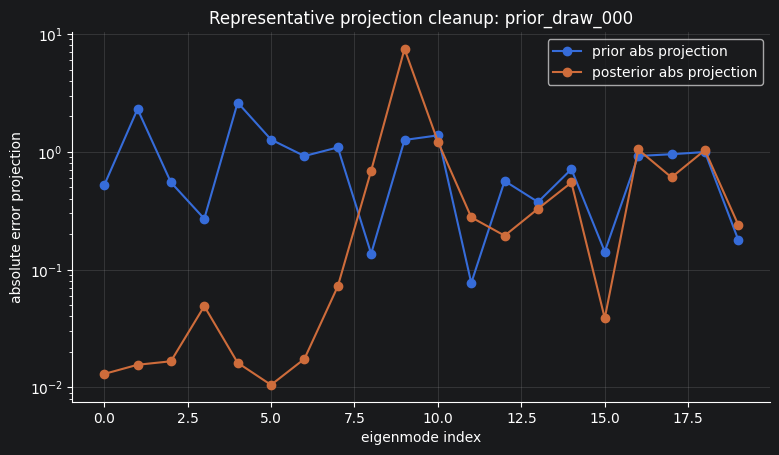

In [29]:
case = sorted(projection["case_name"].unique())[0]
df = projection[projection["case_name"].eq(case)].sort_values("mode_index")
fig, ax = plt.subplots()
ax.plot(df["mode_index"], df["prior_error_projection"].abs(), marker="o", label="prior abs projection")
ax.plot(df["mode_index"], df["posterior_error_projection"].abs(), marker="o", label="posterior abs projection")
ax.set_yscale("log")
ax.set_xlabel("eigenmode index")
ax.set_ylabel("absolute error projection")
ax.set_title(f"Representative projection cleanup: {case}")
ax.legend()
savefig("eigenmode_projection_representative_case.png")
plt.show()


## 11. Subblock Audit Summary

This section checks whether suspicious posterior behavior might be caused by poor recovered-reference fits, masked frames, or Schur summary validity issues. It is especially important before scaling the campaign further.


In [30]:
def get_nested(d: dict, *keys, default=np.nan):
    cur = d
    for key in keys:
        if not isinstance(cur, dict) or key not in cur:
            return default
        cur = cur[key]
    return cur


def flatten_audit(path: Path) -> dict:
    data = load_json(path)
    rel = path.relative_to(RUN_ROOT).parts
    case_name = rel[1] if len(rel) > 1 else None
    subblock_name = rel[2] if len(rel) > 2 else data.get("case_name")
    try:
        subblock_index = int(str(subblock_name).split("_")[-1])
    except ValueError:
        subblock_index = np.nan
    validation = data.get("local_surrogate_validation", {}) or {}
    ratio_stats = validation.get("actual_fixed_phi_to_schur_predicted_ratio_stats", {}) or {}
    theta_consistency = get_nested(data, "theta_reference", "theta_reference_consistency", default={})
    frame_quality = data.get("frame_quality", {}) or {}
    curvature = data.get("curvature", {}) or {}
    warnings = []
    errors = []
    for section in [frame_quality, validation]:
        w = section.get("warning") if isinstance(section, dict) else None
        e = section.get("error") if isinstance(section, dict) else None
        ws = section.get("warnings") if isinstance(section, dict) else None
        if w:
            warnings.append(str(w))
        if isinstance(ws, list):
            warnings.extend(map(str, ws))
        if e:
            errors.append(str(e))
    return {
        "case_name": case_name,
        "subblock_name": subblock_name,
        "subblock_index": subblock_index,
        "curvature_method": curvature.get("schur_curvature_method_used"),
        "dense_global_hessian_materialized": curvature.get("dense_global_hessian_materialized"),
        "structured_curvature_used": curvature.get("structured_curvature_used"),
        "frame_quality_policy": frame_quality.get("policy"),
        "total_frame_count": frame_quality.get("total_frame_count"),
        "good_frame_count": frame_quality.get("good_frame_count"),
        "bad_frame_count": frame_quality.get("bad_frame_count"),
        "final_block_reduced_chi2": frame_quality.get("block_reduced_chi2"),
        "max_final_frame_reduced_chi2": frame_quality.get("max_frame_reduced_chi2"),
        "median_final_frame_reduced_chi2": frame_quality.get("median_frame_reduced_chi2"),
        "surrogate_validation_status": bool(validation.get("exists")) and bool(validation.get("all_nonzero_deltas_match_sign")),
        "surrogate_validation_max_abs_error": ratio_stats.get("max"),
        "theta_reference_consistency_status": theta_consistency.get("passed") if isinstance(theta_consistency, dict) else np.nan,
        "warnings": "; ".join(warnings),
        "errors": "; ".join(errors),
    }

audits = pd.DataFrame([flatten_audit(p) for p in audit_paths]).sort_values(["case_name", "subblock_index"])
summary_cols = [
    "case_name",
    "subblock_index",
    "curvature_method",
    "structured_curvature_used",
    "total_frame_count",
    "good_frame_count",
    "bad_frame_count",
    "final_block_reduced_chi2",
    "max_final_frame_reduced_chi2",
    "median_final_frame_reduced_chi2",
    "surrogate_validation_status",
    "theta_reference_consistency_status",
    "warnings",
    "errors",
]
display(audits[summary_cols].round(4))

case_audit_summary = audits.groupby("case_name", as_index=False).agg(
    subblocks=("subblock_index", "count"),
    total_bad_frames=("bad_frame_count", "sum"),
    max_frame_reduced_chi2=("max_final_frame_reduced_chi2", "max"),
    median_block_reduced_chi2=("final_block_reduced_chi2", "median"),
    surrogate_validation_all_ok=("surrogate_validation_status", "all"),
    theta_reference_consistency_all_ok=("theta_reference_consistency_status", "all"),
)
display(case_audit_summary.round(4))

issues = audits[(audits["warnings"].fillna("").ne("")) | (audits["errors"].fillna("").ne(""))]
display(issues[["case_name", "subblock_index", "warnings", "errors"]] if not issues.empty else pd.DataFrame({"audit warnings/errors": ["none found"]}))


,case_name,subblock_index,curvature_method,structured_curvature_used,total_frame_count,good_frame_count,bad_frame_count,final_block_reduced_chi2,max_final_frame_reduced_chi2,median_final_frame_reduced_chi2,surrogate_validation_status,theta_reference_consistency_status,warnings,errors
0,prior_draw_000,0,structured_independent_frames,True,20,20,0,1.2033,1.2178,1.2031,True,True,,
1,prior_draw_000,1,structured_independent_frames,True,20,20,0,1.2000,1.2110,1.2018,True,True,,
2,prior_draw_000,2,structured_independent_frames,True,20,20,0,1.1983,1.2163,1.1987,True,True,,
3,prior_draw_000,3,structured_independent_frames,True,20,20,0,1.2010,1.2135,1.2018,True,True,,
4,prior_draw_000,4,structured_independent_frames,True,20,20,0,1.2029,1.2260,1.2001,True,True,,
5,prior_draw_001,0,structured_independent_frames,True,20,20,0,1.1981,1.2103,1.2005,True,True,,
6,prior_draw_001,1,structured_independent_frames,True,20,20,0,1.1967,1.2085,1.1960,True,True,,
7,prior_draw_001,2,structured_independent_frames,True,20,20,0,1.2022,1.2243,1.2020,True,True,,
8,prior_draw_001,3,structured_independent_frames,True,20,20,0,1.1979,1.2096,1.1974,True,True,,
9,prior_draw_001,4,structured_independent_frames,True,20,20,0,1.1971,1.2166,1.1953,True,True,,


,case_name,subblocks,total_bad_frames,max_frame_reduced_chi2,median_block_reduced_chi2,surrogate_validation_all_ok,theta_reference_consistency_all_ok
0,prior_draw_000,5,0,1.2260,1.2010,True,True
1,prior_draw_001,5,0,1.2243,1.1979,True,True
2,prior_draw_002,5,0,1.2174,1.1974,True,True
3,prior_draw_003,5,0,1.2222,1.1999,True,True
4,prior_draw_004,5,0,1.2294,1.1961,True,True


,audit warnings/errors
0,none found


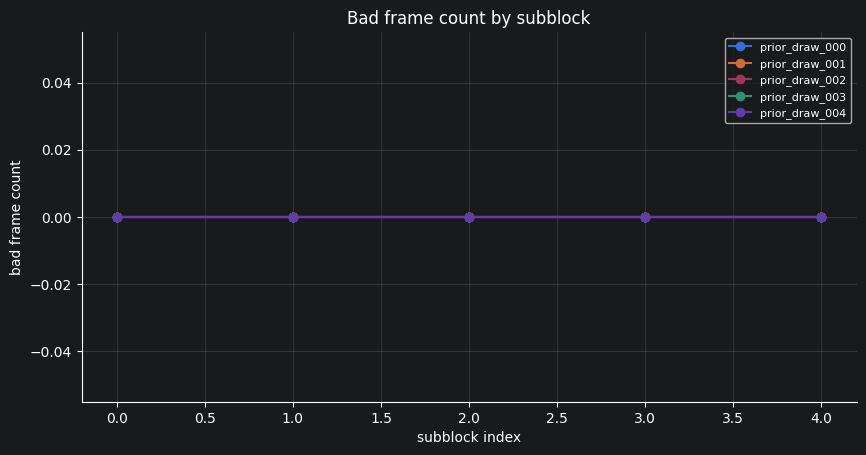

In [31]:
fig, ax = plt.subplots(figsize=(10, 4.8))
for case, df in audits.groupby("case_name"):
    ax.plot(df["subblock_index"], df["bad_frame_count"], marker="o", label=case)
ax.set_xlabel("subblock index")
ax.set_ylabel("bad frame count")
ax.set_title("Bad frame count by subblock")
ax.legend(fontsize=8)
savefig("subblock_audit_bad_frames.png")
plt.show()


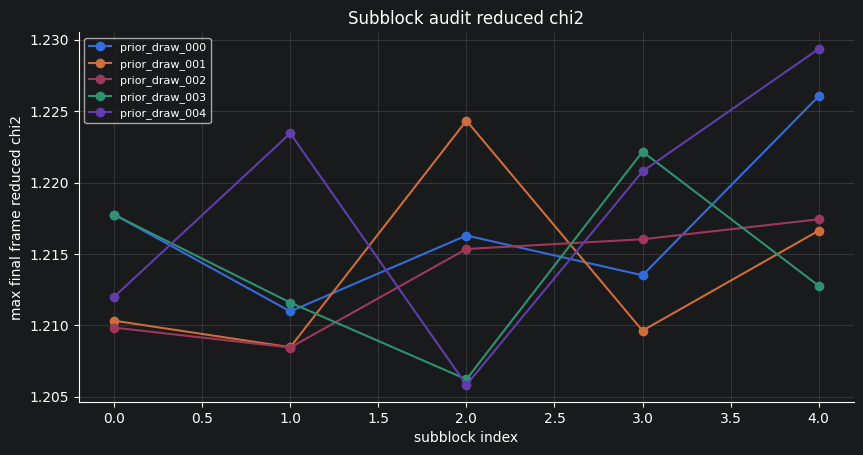

In [32]:
fig, ax = plt.subplots(figsize=(10, 4.8))
for case, df in audits.groupby("case_name"):
    ax.plot(df["subblock_index"], df["max_final_frame_reduced_chi2"], marker="o", label=case)
ax.set_xlabel("subblock index")
ax.set_ylabel("max final frame reduced chi2")
ax.set_title("Subblock audit reduced chi2")
ax.legend(fontsize=8)
savefig("subblock_audit_chi2.png")
plt.show()


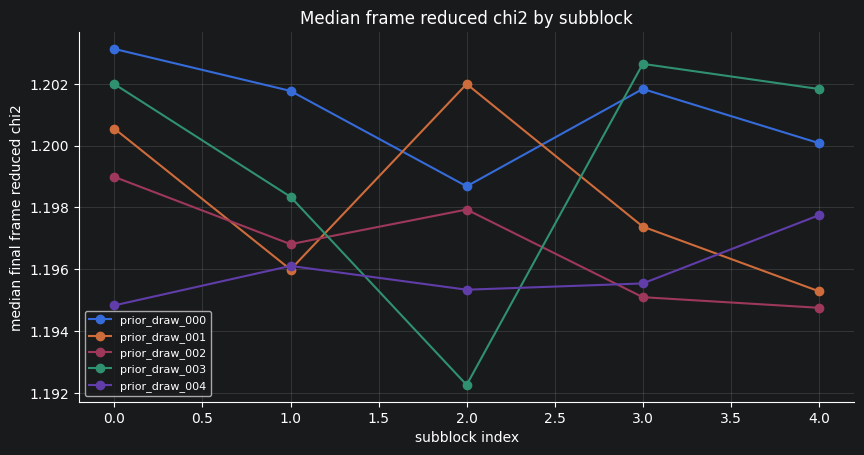

In [33]:
fig, ax = plt.subplots(figsize=(10, 4.8))
for case, df in audits.groupby("case_name"):
    ax.plot(df["subblock_index"], df["median_final_frame_reduced_chi2"], marker="o", label=case)
ax.set_xlabel("subblock index")
ax.set_ylabel("median final frame reduced chi2")
ax.set_title("Median frame reduced chi2 by subblock")
ax.legend(fontsize=8)
savefig("subblock_audit_median_chi2.png")
plt.show()


## 12. Final Interpretation And Next Steps

The campaign infrastructure completed the intended first full-Zernike overnight run and produced both actual image-backed summaries and forecast diagnostics. The actual 5-summary updates remain mostly prior-dominated for separation, while the 1800-subblock fixed-information score-noise forecast suggests useful separation precision if the score-noise model holds. The replicate forecast and coherent log-flux shift are the main caution signs.


In [34]:
traffic_light = pd.DataFrame([
    ("Campaign infrastructure", "green", "Root-level, per-case, forecast, eigenmode, and audit artifacts are present."),
    ("Full-Zernike layout and prior-draw setup", "green", "20-dimensional Theta and five prior draws are represented."),
    ("Actual 5-summary correction", "yellow", "Separation sigma stays near 10 microarcsec; corrections are mostly prior-dominated."),
    ("1800 stochastic forecast", "green/yellow", "Fixed score-noise reaches about 6.4 microarcsec sigma, but remains a forecast."),
    ("Replicate forecast", "yellow/red", "Coherent replicated scores produce much larger separation errors."),
    ("Log-flux behavior", "red/yellow", "Coherent downward posterior shift needs targeted diagnostics."),
    ("Zernike degeneracy exposure", "green", "Weak accumulated-information modes are Zernike-dominated and expose M1/M2 structure."),
    ("Proposal-readiness", "yellow", "Promising, pending score residual, log-flux, and larger real-summary checks."),
], columns=["area", "status", "interpretation"])
display(traffic_light)

next_runs = pd.DataFrame([
    (1, "One prior draw x 20 actual subblocks x 20 frames"),
    (2, "One prior draw x 50 actual subblocks x 20 frames if runtime allows"),
    (3, "No-log-flux layout comparison"),
    (4, "Four-scalar baseline with the same seed policy"),
    (5, "Score-residual / whitened-score residual audit across real summaries"),
], columns=["priority", "recommended next run"])
display(next_runs)


,area,status,interpretation
0,Campaign infrastructure,green,"Root-level, per-case, forecast, eigenmode, and..."
1,Full-Zernike layout and prior-draw setup,green,20-dimensional Theta and five prior draws are ...
2,Actual 5-summary correction,yellow,Separation sigma stays near 10 microarcsec; co...
3,1800 stochastic forecast,green/yellow,Fixed score-noise reaches about 6.4 microarcse...
4,Replicate forecast,yellow/red,Coherent replicated scores produce much larger...
5,Log-flux behavior,red/yellow,Coherent downward posterior shift needs target...
6,Zernike degeneracy exposure,green,Weak accumulated-information modes are Zernike...
7,Proposal-readiness,yellow,"Promising, pending score residual, log-flux, a..."


,priority,recommended next run
0,1,One prior draw x 20 actual subblocks x 20 frames
1,2,One prior draw x 50 actual subblocks x 20 fram...
2,3,No-log-flux layout comparison
3,4,Four-scalar baseline with the same seed policy
4,5,Score-residual / whitened-score residual audit...


### Validation Snapshot

The checks below are lightweight notebook-level confirmations of the main manual-review facts. They do not rerun the campaign or any subblock solve.


In [35]:
fixed_1800 = target[target["forecast_mode"].eq("fixed_information_score_noise")]
replicate_1800 = target[target["forecast_mode"].eq("replicate")]
validation = pd.DataFrame([
    ("cases", science["case_name"].nunique()),
    ("theta_dim", posterior["theta_label"].nunique()),
    ("actual summaries per case", actual_summary_count),
    ("median actual separation sigma [microarcsec]", science["posterior_separation_sigma_microas"].median()),
    ("median 1800 fixed score-noise sigma [microarcsec]", fixed_1800["separation_posterior_sigma_microas"].median()),
    ("median 1800 fixed score-noise RMS error [microarcsec]", fixed_1800["separation_error_rms_microas"].median()),
    ("median 1800 replicate abs error [microarcsec]", replicate_1800["separation_posterior_error_microas"].abs().median()),
    ("log-flux posterior shift all negative", bool((log_flux["posterior_shift"] < 0).all())),
    ("subblock audit files", len(audit_paths)),
], columns=["check", "value"])
display(validation)


,check,value
0,cases,5
1,theta_dim,20
2,actual summaries per case,5
3,median actual separation sigma [microarcsec],9.961873
4,median 1800 fixed score-noise sigma [microarcsec],6.377698
5,median 1800 fixed score-noise RMS error [micro...,5.758964
6,median 1800 replicate abs error [microarcsec],212.915546
7,log-flux posterior shift all negative,True
8,subblock audit files,25
